In [1]:
# importing packages

import os 
import pandas as pd
import numpy as np
np.int= int
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import RidgeCV

from pyESD.ESD_utils import store_pickle, Dataset
from pyESD.Weatherstation import read_station_csv
from pyESD.standardizer import MonthlyStandardizer
from pyESD.teleconnections import NAO, eof_analysis
from pyESD.metrics import Evaluate
from pyESD.models import Regressors
from pyESD.standardizer import YearlyStandardizer

In [2]:
cachedir = r"C:\Users\danis\Desktop\Danish\ERA5 Data\PYESD_CACHE"
os.makedirs(cachedir, exist_ok=True)

In [3]:
variable= ['Bs'] # or Bs, Ba

# time splits
train_range        = pd.date_range("1950-01-01", "2010-01-01", freq="YS")
test_range         = pd.date_range("2011-01-01", "2023-01-01", freq="YS")
complete_range     = pd.date_range("1950-01-01", "2023-01-01", freq="YS")

# pre2k_complete      = pd.date_range("1950-01-01", "2000-01-01", freq="YS")
# pre2k_train_range   = pd.date_range("1950-01-01", "1985-01-01", freq="YS")
# pre2k_test_range    = pd.date_range("1986-01-01", "2000-01-01", freq="YS")

# post2k_complete     = pd.date_range("2000-01-01", "2023-01-01", freq="YS")
# post2k_train_range  = pd.date_range("2000-01-01", "2012-01-01", freq="YS")
# post2k_test_range   = pd.date_range("2013-01-01", "2023-01-01", freq="YS")

predictors=["t2m", "tp", "u10", "v10", "ssrd", "NAO", "EA"]

In [4]:
mjjas_mean_dir = r"C:\Users\danis\Desktop\Danish\ERA5 Data\MJJAS_MEANS"
predictor_dir= r"C:\Users\danis\Desktop\Danish\ERA5 Data"

ERA5Data = Dataset(name="ERA5", domain_name='NH', variables={
    "t2m":  os.path.join(mjjas_mean_dir, "MJJAS_MEANS_t2m.nc"),
    "tp":   os.path.join(mjjas_mean_dir, "MJJAS_MEANS_tp.nc"),
    "v10":  os.path.join(mjjas_mean_dir, "MJJAS_MEANS_v10.nc"),
    "u10":  os.path.join(mjjas_mean_dir, "MJJAS_MEANS_u10.nc"),
    "ssrd": os.path.join(mjjas_mean_dir, "MJJAS_MEANS_ssrd.nc"),
    "msl":  os.path.join(predictor_dir, "msl.nc"), 
})
ERA5Data

In [5]:
glaciernames = ['Alfotbreen', 'Austdalsbreen', 'Engabreen', 'Grafjellsbrea', 'Grasubreen', 
                             'Hansebreen', 'Hellstugubreen', 'Langfjordjokelen', 'Nigardsbreen', 'Rembesdalskaka', 'Storbreen']

## Creating short form dictinary for glacier names

glacier_shortnames = {'Alfotbreen': 'Alf', 
                        'Austdalsbreen': 'Aus', 
                        'Engabreen': 'Eng', 
                        'Grafjellsbrea': 'Graf', 
                        'Grasubreen': 'Gras', 
                        'Hansebreen': 'Han', 
                        'Hellstugubreen': 'Hell', 
                        'Langfjordjokelen': 'Lan',
                        'Nigardsbreen': 'Nig', 
                        'Rembesdalskaka': 'Rem', 
                        'Storbreen': 'Sto'}

glacier_datadir= r"C:\Users\danis\Desktop\Danish\NVE\glaciers\Mass Balance\Cleaned"
glaciers = {}

In [6]:
regressors= ['RidgeCV', 'Bagging', 'ARD', 'RandomForest', 'XGBoost', 'BayesianRidge']

regressor_shortnames = {
    "RandomForest": "RF",
    "ARD": "ARD",
    "RidgeCV": "Ridge",
    "XGBoost": "XGB",
    "Bagging": "Bag",
    "BayesianRidge": "BYR"

}
selector_shortnames = {
    "Recursive": "Rec",
    "Sequential": "Seq",
    "TreeBased": "Tree"
}

In [7]:
results = []
# results_dir= r"C:\Users\danis\Desktop\Danish\Scripts_Python\Results"
results_dir = r"C:\Users\danis\Desktop\Danish\Thesis Model Results (Appendix)"

In [8]:
for variable in ['Bs']:
    print(f"\n===== Running model for variable: {variable} =====")
    
    for name in glacier_shortnames:
        print(f"\n--- Processing Station: {name} ---")

        for regressor in regressors:
            print (f"\n--- Running Regressor: {regressor} ===")

            glacier_file = os.path.join(glacier_datadir, f"{name}_cleaned.csv")
            GO = read_station_csv(filename=glacier_file, varname=variable) 
            glaciers[name] = GO

            available_train_range = [d for d in train_range if d in GO.get_var(variable, None).index]
            available_test_range  = [d for d in test_range if d in GO.get_var(variable, None).index]

            # 1. defining model predictors
            GO.set_predictors(variable=variable, predictors= predictors, 
                              cachedir=cachedir)

            y = GO.get_var(variable, available_train_range)
            print(f"{variable} @ {name}: Missing months:", y.isna().sum())
            if y.dropna().shape[0] < 12:
                print(f"⚠️ Skipping {name} — insufficient glacier data")
                continue

            # 2. setting standardardizer
            GO.set_standardizer(variable, standardizer= YearlyStandardizer(detrending=True, scaling=True))
    
            # 3. defining scoring metrics
            scoring= ['neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error']
    
             # 4. training model
            GO.set_model(variable=variable,
                         method= regressor,
                         predictor_dataset=ERA5Data,
                         daterange=available_train_range,
                         scoring= scoring,
                         cv=KFold(n_splits=10))
    
            # 5. setting selectors
            for selector_method in ['Recursive', 'Sequential', 'TreeBased']:
                print(f"     -> Selector method: {selector_method}")
    
                if selector_method == 'Recursive':
                    GO.fit(variable, available_train_range, ERA5Data, fit_predictors=True,
                           predictor_selector=True, selector_method=selector_method,
                           selector_regressor= 'ARD', cal_relative_importance=False)
                    
                elif selector_method == 'TreeBased':
                    GO.fit(variable, available_train_range, ERA5Data, fit_predictors=True,
                           predictor_selector=True, selector_method=selector_method,
                           selector_regressor='ExtraTree')
    
                elif selector_method == 'Sequential':
                    GO.fit(variable, available_train_range, ERA5Data, fit_predictors=True,
                           predictor_selector=True, selector_method=selector_method,
                           select_regressor= 'ARD', num_predictors= 2, selector_direction='forward')
    
                else:
                    raise ValueError('Selector method not recognized')
    
                
                selected_predictors = GO.selected_names(variable)
                ypred = GO.predict(variable, available_test_range, ERA5Data)
    
                # 6. cross validate and predict for training period
                #score_1950to2010, ypred_1950to2010 = GO.cross_validate_and_predict(variable, available_train_range, ERA5Data)
                score_train, ypred_train= GO.cross_validate_and_predict(variable, available_train_range, ERA5Data)

                # 7. prediction for training period
                #ypred_1950to2010 = GO.predict(variable, available_train_range, ERA5Data)
                ypred_train = GO.predict(variable, available_train_range, ERA5Data)

                # 8. prediction for testing period
                #ypred_2011to2022 = GO.predict(variable, available_test_range , ERA5Data)
                ypred_test = GO.predict(variable, available_test_range, ERA5Data)
          
                # 9. Evaluate metrics using test predictions
                y_true_test = GO.get_var(variable, available_test_range)
                evaluator = Evaluate(y_true_test, ypred_test)
                r2 = evaluator.R2_score()
                rmse = evaluator.RMSE()
                mae = evaluator.MAE()
                            
                # 10. Save results
                # results.append({
                #     "Variable": variable,
                #     "Glacier": glacier_shortnames[name],
                #     "Regressor": regressor_shortnames[regressor],
                #     "Selector": selector_shortnames[selector_method],
                #     "Predictors": selected_predictors,
                #     "R2": r2,
                #     "RMSE": rmse,
                #     "MAE": mae
                # })

                # Saving results in a structured format for thesis
                results.append({
                    "Glacier": glacier_shortnames[name],
                    "Model_Combination": f"{regressor_shortnames[regressor]} + {selector_shortnames[selector_method]}",
                    "Model_Type": "Linear" if regressor_shortnames[regressor] in ["RidgeCV", "ARD", "BayesianRidge"] else "Non-linear",
                    "R2": round(r2, 3),
                    "RMSE": round(rmse, 3)
                })

                df_preds = pd.DataFrame({
                    "Date": GO.get_var(variable, available_train_range).index,
                    "Observed": GO.get_var(variable, available_train_range).values,
                    "Predicted": ypred_train
                })
    
                #filename = os.path.join(results_dir, f"predictions_{name}_{regressor}_{selector_method}.csv")
                #df_preds.to_csv(filename, index=False)
    
                print(f"Done with {regressor} for {name} using {selector_method}. Selected predictors: {selected_predictors}")

results_df= pd.DataFrame(results)


===== Running model for variable: Bs =====

--- Processing Station: Alfotbreen ---

--- Running Regressor: RidgeCV ===
Alfotbreen 61.75 5.65 1180.0
Bs @ Alfotbreen: Missing months: 0
     -> Selector method: Recursive
5 : optimal number of predictors and selected variables are Index(['t2m', 'tp', 'u10', 'NAO', 'EA'], dtype='object')
R² (Coefficient of determinaiton): 0.37
RMSE: 0.739667
Mean Absolute Error): 0.51
Done with RidgeCV for Alfotbreen using Recursive. Selected predictors:    t2m  tp  u10  NAO  EA
0  t2m  tp  u10  NAO  EA
     -> Selector method: Sequential
2 : optimal number of predictors and selected variables are Index(['tp', 'v10'], dtype='object')
R² (Coefficient of determinaiton): -0.03
RMSE: 0.944876
Mean Absolute Error): 0.74
Done with RidgeCV for Alfotbreen using Sequential. Selected predictors:    tp  v10
0  tp  v10
     -> Selector method: TreeBased
3 : optimal number of predictors and selected variables are Index(['t2m', 'NAO', 'EA'], dtype='object')
R² (Coeffici

c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python3

R² (Coefficient of determinaiton): -1.05
RMSE: 2.292664
Mean Absolute Error): 1.99
Done with RidgeCV for Grafjellsbrea using Recursive. Selected predictors:    tp  u10  v10  NAO  EA
0  tp  u10  v10  NAO  EA
     -> Selector method: Sequential
2 : optimal number of predictors and selected variables are Index(['tp', 'NAO'], dtype='object')


c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python3

R² (Coefficient of determinaiton): -0.42
RMSE: 1.907761
Mean Absolute Error): 1.62
Done with RidgeCV for Grafjellsbrea using Sequential. Selected predictors:    tp  NAO
0  tp  NAO
     -> Selector method: TreeBased
2 : optimal number of predictors and selected variables are Index(['u10', 'ssrd'], dtype='object')


c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\danis\AppData\Local\Programs\Python\Python3

R² (Coefficient of determinaiton): -0.93
RMSE: 2.222881
Mean Absolute Error): 1.78
Done with RidgeCV for Grafjellsbrea using TreeBased. Selected predictors:    u10  ssrd
0  u10  ssrd

--- Running Regressor: Bagging ===
Grafjellsbrea 60.1 6.38 1320.0
Bs @ Grafjellsbrea: Missing months: 0
     -> Selector method: Recursive
5 : optimal number of predictors and selected variables are Index(['tp', 'u10', 'v10', 'NAO', 'EA'], dtype='object')
R² (Coefficient of determinaiton): -1.32
RMSE: 2.440282
Mean Absolute Error): 2.08
Done with Bagging for Grafjellsbrea using Recursive. Selected predictors:    tp  u10  v10  NAO  EA
0  tp  u10  v10  NAO  EA
     -> Selector method: Sequential
2 : optimal number of predictors and selected variables are Index(['tp', 'NAO'], dtype='object')
R² (Coefficient of determinaiton): -1.36
RMSE: 2.458660
Mean Absolute Error): 2.05
Done with Bagging for Grafjellsbrea using Sequential. Selected predictors:    tp  NAO
0  tp  NAO
     -> Selector method: TreeBased
3 : o

In [9]:
metrics_path = os.path.join(results_dir, "model_metrics_bs.csv")
results_df.to_csv(metrics_path, index=False)

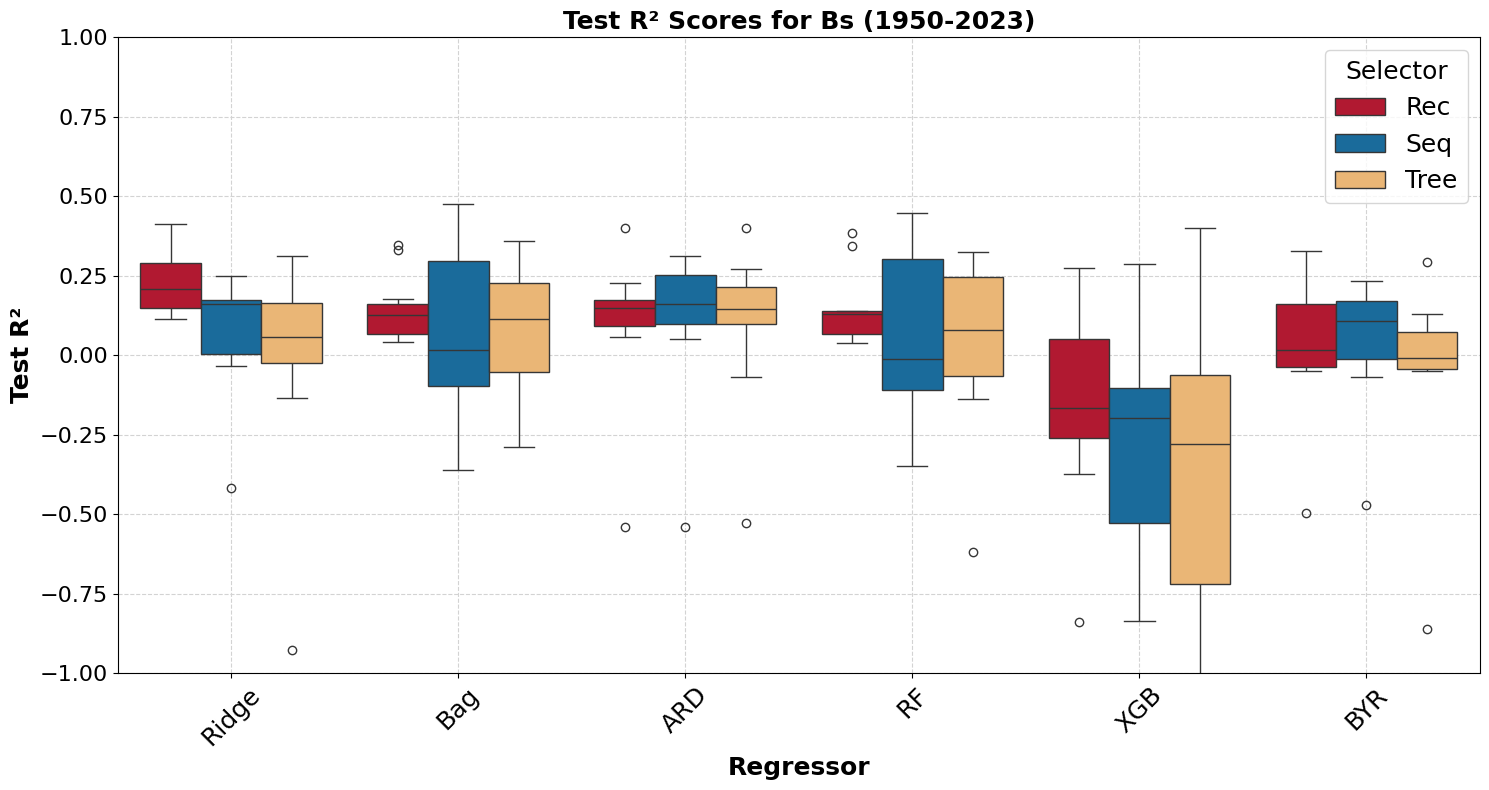

In [ ]:
metrics_path = os.path.join(results_dir, "model_metrics_bs.csv")
df = pd.read_csv(metrics_path)
#df= results_df

# Define custom colors for Selector methods
colors = {
    "Rec": "#ca0020",   # red
    "Seq": "#0571b0",  # blue
    "Tree": "#fdb863"    # orange-yellow
}

gridline_color = "#d3d3d3"
variables = ["Bs"]

for var in variables:
    fig, ax = plt.subplots(figsize=(15, 8))
    sns.boxplot(data=df[df["Variable"] == var], x="Regressor", y="R2", hue="Selector", palette=colors, ax=ax)

    ax.set_title(f"Test R² Scores for {var} (1950-2023)", fontsize=18, fontweight="bold")
    ax.set_ylabel("Test R²", fontsize=18, fontweight="bold")
    ax.set_xlabel("Regressor", fontsize=18, fontweight="bold")
    ax.grid(True, linestyle="--", color=gridline_color)
    ax.legend(title="Selector", title_fontsize=18, fontsize=18)
    ax.set_ylim(-1, 1)

    plt.yticks(size=16)
    plt.xticks(rotation=45, size=18)
    plt.tight_layout()
    #plt.savefig(f"boxplot_r2_bs_complete.png", dpi=800, bbox_inches='tight')
    plt.show()


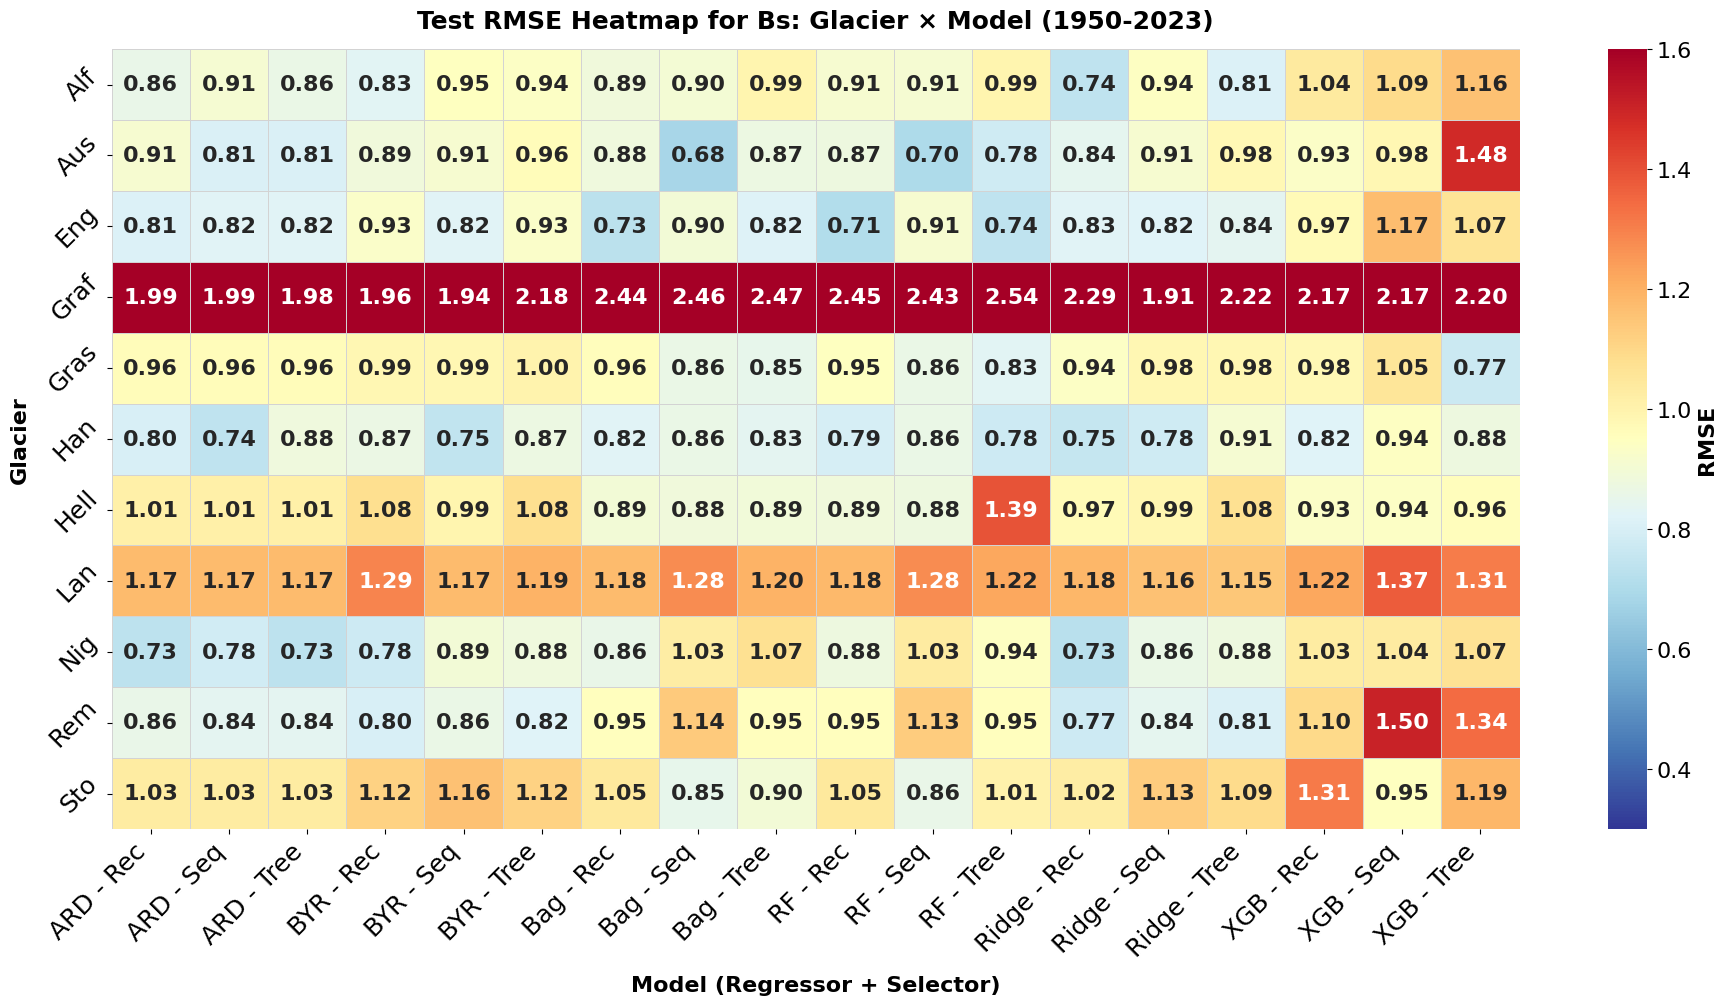

In [11]:
# Load results
results_df = pd.read_csv(r"C:\Users\danis\Desktop\Danish\Scripts_Python\Results\model_metrics_bs.csv")

# Create combined model column
results_df["Model"] = results_df["Regressor"] + " - " + results_df["Selector"]

# Pivot table
pivot_df = results_df.pivot_table(index="Glacier", columns="Model", values="RMSE", aggfunc='mean')

gridline_color = "#d3d3d3"  # light grey
plt.figure(figsize=(20, 10))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5,
    linecolor=gridline_color,
    cbar_kws={'label': 'RMSE'},
    annot_kws={"fontsize": 16, "fontweight": "bold"},
    vmax= 1.6,
    vmin= 0.3
)

cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=16)
cbar.set_ylabel("RMSE", fontsize=16, fontweight="bold")

plt.title("Test RMSE Heatmap for Bs: Glacier × Model (1950-2023)", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Model (Regressor + Selector)", fontsize=16, fontweight="bold", labelpad=10)
plt.ylabel("Glacier", fontsize=16, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(rotation=45, fontsize=18)

plt.tight_layout()
plt.subplots_adjust(left=0.07, right=0.95, top=0.93, bottom=0.15)
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\09- Bs Model Routine\Complete\heatmap_rmse_bw_complete.png", dpi=800, bbox_inches='tight')
plt.show()